<div style="background-color: #050505; padding: 25px; border: 1px solid #4a0000; box-shadow: inset 0 0 15px #330000;">
    <p style="font-family: 'Courier New', monospace; color: #ff1a1a; font-size: 18px; text-shadow: 0px 0px 8px #ff0000; letter-spacing: 2px;">
        The DARK SECRET Behind Intro-to-DL's Task 9.
    </p>
</div>

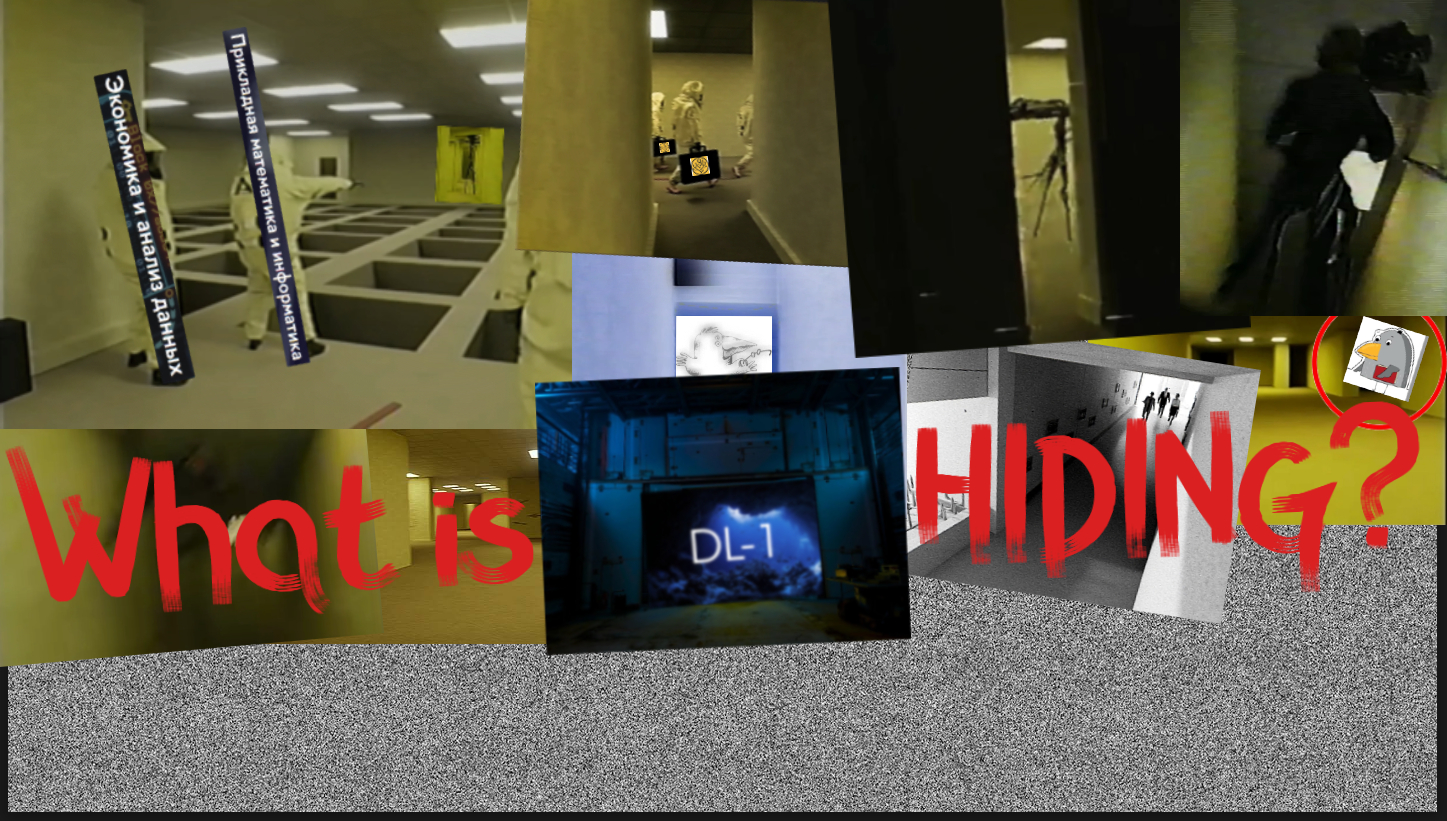

In [1]:
import cv2
import numpy as np

video_path = 'task.mp4'
cap = cv2.VideoCapture(video_path)

ret, first_frame = cap.read()

accumulator = np.zeros_like(first_frame, dtype=np.float32)
frame_count = 0

cap.set(cv2.CAP_PROP_POS_FRAMES, 0)

while True:
    ret, frame = cap.read()
    if not ret:
        break
        
    accumulator += frame
    frame_count += 1

cap.release()

average_frame = accumulator / frame_count
average_frame = np.array(np.round(average_frame), dtype=np.uint8)

gray_result = cv2.cvtColor(average_frame, cv2.COLOR_BGR2GRAY)

denoised = cv2.medianBlur(gray_result, 3)

blurred = cv2.GaussianBlur(denoised, (5, 5), 0)

_, final_clean_text = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

output_filename = 'revelaed_secret.png'
cv2.imwrite(output_filename, final_clean_text)

print(f"Mystery solved! Checkout the '{output_filename}'.")

Mystery solved! Checkout the 'revelaed_secret.png'.


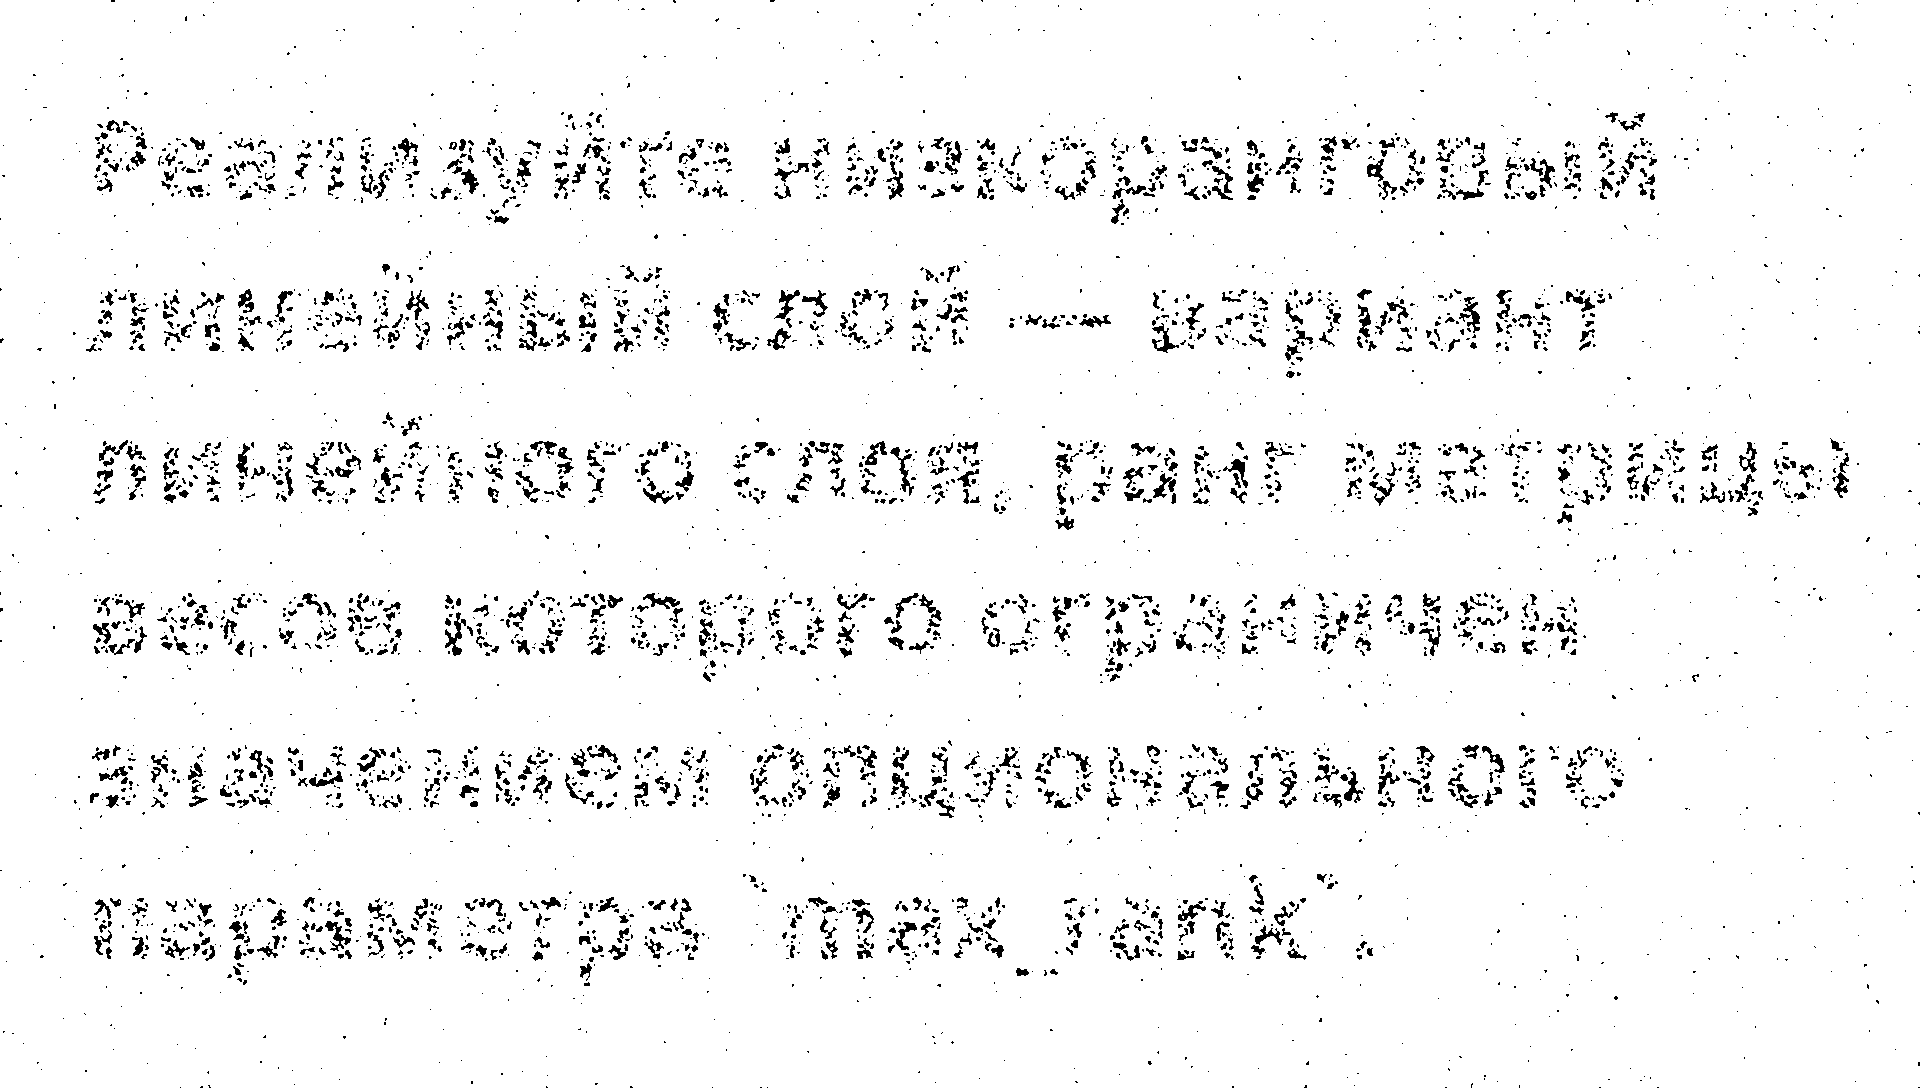